# Network Science Data - Assignment 3
- Course: PHYS 7332
- Semester: Fall 2024
- Date: November 11, 2024
- Name: Minami Ueda (ueda.m@northeastern.edu)
- Environment: `/work/netsi/ueda.m/conda/netsi`

Answers for Question 1(a), Question 3

## Setup

In [1]:
import networkx as nx
import community
from tqdm import tqdm
from tqdm import trange
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = False 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'

In [4]:
os.chdir('/work/netsi/ueda.m/network-science-data/assignments/assignment3')
print("working directory:", os.getcwd())

working directory: /work/netsi/ueda.m/network-science-data/assignments/assignment3


***
## Question 1: Community detection

### Question 1(a)

In [4]:
m_list = [i for i in range(1,5+1)] # 1 to 5
m_list

[1, 2, 3, 4, 5]

In [5]:
system_size_sequence = [N for N in range(50,300+1,50)]
system_size_sequence

[50, 100, 150, 200, 250, 300]

In [6]:
system_size_sequence_small_step = [N for N in range(50,350+1,1)]

#### Theoretical value calculation
Equation 21 from the paper
$$
M_{SF}(S,m) = \bigg( a + \frac{1-a}{m} \bigg) \bigg( 1 - \frac{2}{\sqrt{S}} \bigg)
$$

In [7]:
def calc_theoretical_modularity(system_size, m, a=0.165):
    return ( a + ((1-a)/m) ) * ( 1 - (2/np.sqrt(system_size)) )

In [8]:
modularity_theoretical_by_m = {}

In [41]:
# Calculate the theoretical value for modularity based on Eq 21

for m in tqdm(m_list):
    modularity_theoretical_by_m[m] = []
    
    for N in system_size_sequence_small_step:

        # Theoretical!
        modularity = calc_theoretical_modularity(system_size=N, m=m)
        modularity_theoretical_by_m[m].append(modularity)


100%|██████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 775.60it/s]


#### Simulation

In [79]:
modularity_observed_by_m = {}

In [80]:
# Calculate modularity for simulated BA model graph

for m in tqdm(m_list):
    modularity_observed_by_m[m] = []
    
    for N in system_size_sequence:
        
        # Scale-free network with differnt N and m
        G = nx.barabasi_albert_graph(n=N, m=m)

        # Get the best partition and the modularity for it
        partition = community.best_partition(G)
        modularity = community.modularity(partition, G)
        
        modularity_observed_by_m[m].append(modularity)
        

 40%|████████████████████████████▍                                          | 2/5 [00:00<00:00, 11.48it/s]

100%|███████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  8.59it/s]


In [86]:
file_path = "out/modularity_observed_by_m.pkl"
if not os.path.exists(file_path):
    print("Saving modularity")
    with open(file_path, 'wb') as f:
        pickle.dump(modularity_observed_by_m, f)
    print(f"Save complete.")

#### Plot

In [70]:
plot_options_by_m = {
    1: {'marker':'o', 'edgecolors':'black', 'facecolors':'white'},
    2: {'marker':'s', 'edgecolors':'black', 'facecolors':'black'},
    3: {'marker':'D', 'edgecolors':'black', 'facecolors':'white'},
    4: {'marker':'^', 'edgecolors':'black', 'facecolors':'black'},
    5: {'marker':'<', 'edgecolors':'black', 'facecolors':'white'}
}

In [71]:
from matplotlib.ticker import MultipleLocator

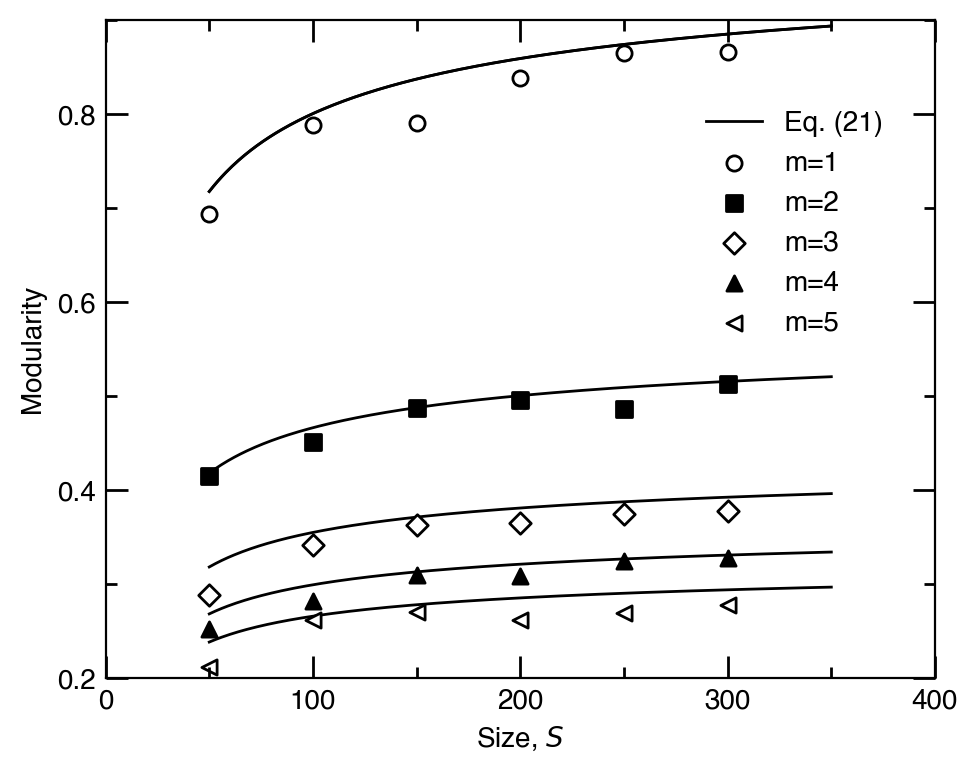

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Just for the legend of theoretical value (line)
line, = ax.plot(
    [N for N in range(50, 350 + 1, 1)],
    modularity_theoretical_by_m[m_list[0]],  # just for creating a legend entry
    zorder=0,
    linewidth=1,
    color='black',
    label="Eq. (21)"
)

# Plot
for m in m_list:
    # Theoretical values as line
    ax.plot(
        system_size_sequence_small_step,
        modularity_theoretical_by_m[m],
        zorder=0,
        linewidth=1,
        color='black'
    )

    # Observed as dots
    ax.scatter(
        system_size_sequence,
        modularity_observed_by_m[m],
        **plot_options_by_m[m],
        s=30,
        zorder=1,
        label=f"m={m}"
    )

ax.set_title("", loc='left')
ax.set_xlabel("Size, $S$")
ax.set_ylabel("Modularity")

# Inner ticks
ax.tick_params(axis='both', direction='in', which='major', top=True, right=True, length=8, width=1)
ax.tick_params(axis='both', direction='in', which='minor', top=True, right=True, length=4, width=1)


y_major_ticks = MultipleLocator(0.2)  # Major ticks at 0.2, 0.4, ..., 0.8
y_minor_ticks = MultipleLocator(0.1)  # Minor ticks at 0.1, 0.2, ..., 0.9
ax.yaxis.set_major_locator(y_major_ticks)
ax.yaxis.set_minor_locator(y_minor_ticks)

# Configure x-axis ticks
x_major_ticks = MultipleLocator(100)  # Major ticks at 100, 200, ..., 400
x_minor_ticks = MultipleLocator(50)   # Minor ticks at 50, 100, ..., 400
ax.xaxis.set_major_locator(x_major_ticks)
ax.xaxis.set_minor_locator(x_minor_ticks)

# Plot range
ax.set_xlim(0, 400)
ax.set_ylim(0.2, 0.9)

# Legend at custom location
fig.legend(bbox_to_anchor=(0.92, 0.88), frameon=False)

fig.tight_layout()

fig.savefig('figure/modularity_by_system_size.pdf', bbox_inches='tight')

plt.show()


### Question 1(b)-(d)
Implementations are in the separate notebook, due to the environment dependencies for `graph-tool`.

***
## Question 2: Flashcard

In [65]:
def logistic(z):
    return 1 / (1 + np.exp(-z))

In [66]:
z_values = np.linspace(-10, 10, 300)
# Apply softmax to the logits
logistic_probs = logistic(z_values)

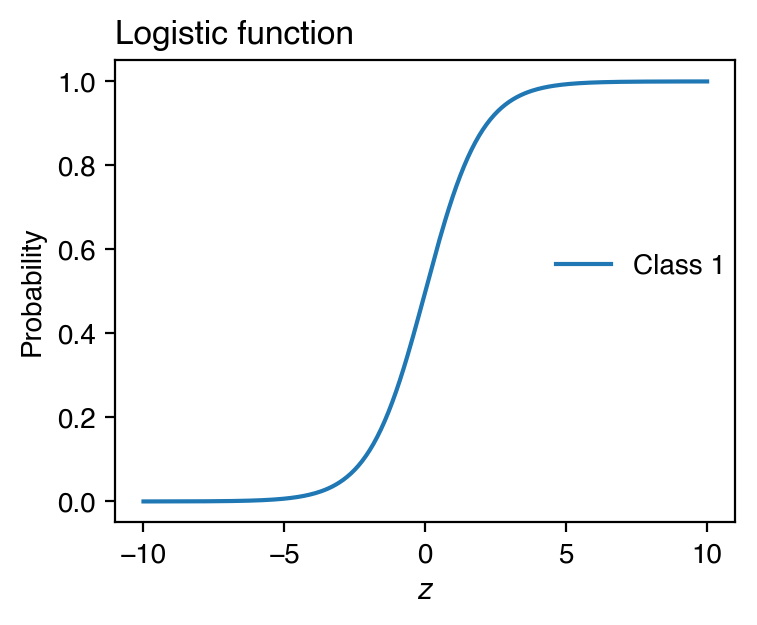

In [69]:

fig, ax = plt.subplots(1,1, figsize=(4,3))

ax.plot(z_values, logistic_probs, label=f'Class 1')

ax.set_title("Logistic function", loc='left')
ax.set_xlabel("$z$")
ax.set_ylabel("Probability")

fig.legend(bbox_to_anchor=(0.92, 0.6), frameon=False)

plt.savefig('figure/logistic.pdf', bbox_inches='tight')

plt.show()


In [5]:
def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z, axis=0)

In [62]:
z_values = np.linspace(-10, 10, 300)
logits = np.array([
    -0.1 * (z_values - 5)**2 + 5,  # Peak near z=5
    -0.1 * (z_values + 5)**2 + 5,  # Peak near z=-5
    -0.1 * (z_values + 0)**2 + 5   # Peak near z=0 
])
softmax_probs = softmax(logits)


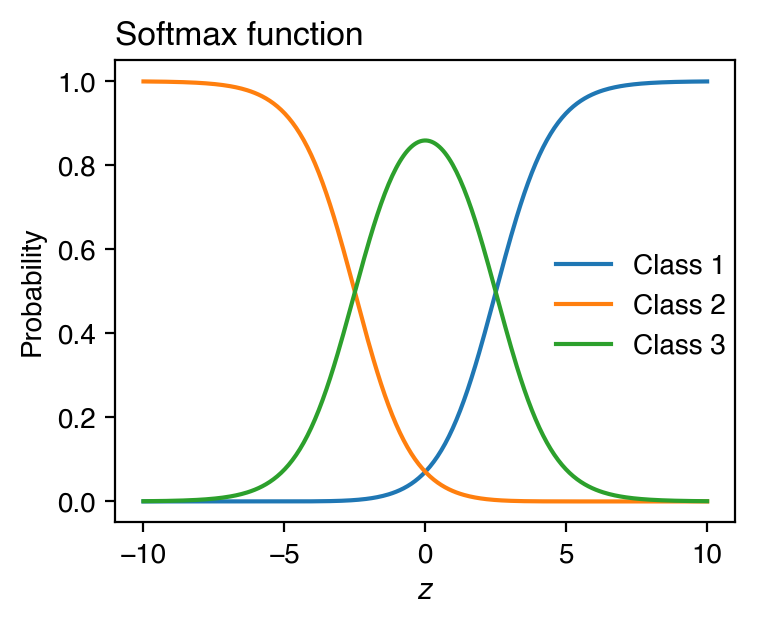

In [64]:
# Generate logits with three modes (distinct peaks for each class)

fig, ax = plt.subplots(1,1, figsize=(4,3))

for i, probs in enumerate(softmax_probs):
    ax.plot(z_values, probs, label=f'Class {i+1}')

ax.set_title("Softmax function", loc='left')
ax.set_xlabel("$z$")
ax.set_ylabel("Probability")

fig.legend(bbox_to_anchor=(0.92, 0.6), frameon=False)

plt.savefig('figure/softmax.pdf', bbox_inches='tight')

plt.show()


In [ ]:
# Confirm that the probability for each class sums to 1
np.sum(softmax_probs, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

***
## Question 3: Random walk dynamics

In [4]:
import random

### Q3(a): Mean commute time (MCT)

#### First passage time 

In [ ]:
def first_passage_time_between_nodes(G, i, j, neighbors_dict=None):
    """
    Computes the first passage time m_{ij} between two nodes in a graph.

    The first passage time is the number of steps required for a random walker 
    to move from node i to node j for the first time.

    Parameters
        i (node)
            The starting node for the random walk.
        j (node)
            The target node for the random walk.

    Returns
        first_passage_time : int
            The number of steps required for the walker to move from node i to node j.
    """
    # Initialize the starting node and the current node
    source = i
    current_node = i
    t = 0  # Initialize the step count
    
    # Continue walking until the target node is reached
    while current_node != j:

        if neighbors_dict is None:
            # Get the neighbors of the current node
            neighbors = list(G.neighbors(current_node))
        else:
            neighbors = neighbors_dict[current_node]
        
        # Choose a random neighbor and move there
        target = random.choice(neighbors)
        current_node = target  # Update the current node
        t += 1                 # Increment the step count
    
    return t  # Return the first passage time between the two nodes

#### Mean first passage time 

In [ ]:
def mean_first_passage_time(G, i, j, niter=100, neighbors_dict=None):
    """
    Computes the mean first passage time between two nodes in a graph.

    Parameters:
        G (networkx.Graph):
            The graph on which to compute the mean first passage time.
        i (node)
            The starting node for the random walk.
        j (node)
            The target node for the random walk.
        niter (int, default=100)
            The number of iterations to perform.
        neighbors_dict (dict, optional)
            A dictionary containing the neighbors of each node for faster computation.  
            Key is the node and value is a list of neighbors.  
            Use `get_neighbors_dict(G)` to get the neighbors dictionary.
    
    Returns:
        mean_fpt (float)
            The mean first passage time between the two nodes.
    """
    fpt_array = []
    for t in range(niter):
        fpt = first_passage_time_between_nodes(G, i, j, neighbors_dict=neighbors_dict)
        fpt_array.append(fpt)

    return np.mean(fpt_array)


In [ ]:
# Test it out with karate club graph
G_karate = nx.karate_club_graph()

In [9]:
first_passage_time_between_nodes(G_karate, 0, 1)

6

In [10]:
mean_first_passage_time(G_karate, 0, 1, niter=1000)

np.float64(19.932)

#### Mean commute time (MCT)
"An interesting approach is based on the concept of mean first-passage time mij of a random walker (see Section 3.2.5) and its symmetrization mij+mji
(the so-called ‘‘mean commute time’’) [359].""

In [ ]:
def mean_commute_time(G, i, j, niter=1000, neighbors_dict=None):
    """
    Compute the mean commute time between two nodes in a graph.

    Parameters:
        G (networkx.Graph)
            The graph on which to compute the mean commute time.
        i (node)
            The starting node for the random walk.
        j (node)
            The target node for the random walk.
        niter (int, default=100)
            The number of iterations to perform.
        neighbors_dict (dict, optional)
            A dictionary containing the neighbors of each node for faster computation.  
            Key is the node and value is a list of neighbors.  
            Use `get_neighbors_dict(G)` to get the neighbors dictionary.
    
    Returns:
        mct (float):
            The mean commute time between the two nodes.
            
    """

    m_ij = mean_first_passage_time(G, i, j, niter=niter, neighbors_dict=neighbors_dict)
    m_ji = mean_first_passage_time(G, j, i, niter=niter, neighbors_dict=neighbors_dict)

    mct = np.sum([m_ij, m_ji])
    
    return mct

In [12]:
# Test mean_commute_time
mean_commute_time(G_karate, 0, 1, niter=1000)

np.float64(31.831000000000003)

#### MCT for 3 randomly selected pairs of nodes

In [13]:
from itertools import combinations

In [ ]:
# Select 3 pairs from karate club nodes
selected_pairs = random.sample(
    list(combinations(list(G_karate.nodes()), 2)),
    3
)
selected_pairs

[(16, 25), (17, 24), (3, 25)]

In [ ]:
# Calculate the mean commute time for the selected pairs
mct_dict = {}
for (i,j) in tqdm(selected_pairs):
    mct = mean_commute_time(G_karate, i, j, niter=1000)
    mct_dict[(i,j)] = mct

  0%|                                                                               | 0/3 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  5.77it/s]


In [17]:
mct_dict

{(16, 25): np.float64(232.636),
 (17, 24): np.float64(174.688),
 (3, 25): np.float64(120.795)}

### Q3(b) MCT for BA and ER network

#### Helper functions

In [18]:
# m_ij cannot be calculated for disconnected graphs
def extract_largest_connected_component(G):
    lcc = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc).copy()

In [ ]:
def get_neighbors_dict(G):
    """
    Get a dictionary containing the neighbors of each node in the graph. By passing the neighbors dictionary, we can reduce the computation time.

    Parameters:
        G (networkx.Graph):
            The graph for which to get the neighbors dictionary.
    
    Returns:
        neighbors_dict (dict):
            A dictionary containing the neighbors of each node in the graph.
            Key is the node and value is a list of neighbors.
    """
    neighbors_dict = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        neighbors_dict[node] = neighbors
    return neighbors_dict

In [ ]:
import os
import pickle

def save_object_to_pickle(obj, file_path):
    """
    Saves an object to a pickle file only if the file does not exist.

    Parameters:
        obj:
            The object to save.
        file_path:
            Path to the pickle file.
    """
    if not os.path.exists(file_path):
        with open(file_path, 'wb') as f:
            pickle.dump(obj, f)
        print(f"Object saved to {file_path}")
    else:
        print(f"File {file_path} already exists. Skipping save.")

In [151]:
def read_pickle(file_path):
    """
    Reads an object from a pickle file.

    Parameters:
        file_path:
            Path to the pickle file.

    Returns:
        obj:
            The object read from the pickle file.
    """
    with open(file_path, 'rb') as f:
        obj = pickle.load(f)
    return obj

#### ER graph

In [ ]:
G_ERs = []
for _ in range(10):
    G_ERs.append(
        nx.gnm_random_graph(n=500, m=8*500/2)
    )

In [ ]:
# Check connectivity for each graph
[nx.is_connected(G) for G in G_ERs]

[True, True, False, True, False, True, True, True, True, True]

In [ ]:
# Extract largest connected component
G_ERs_LCC = []
for G in G_ERs:
    G_ERs_LCC.append(
        extract_largest_connected_component(G)
    )

In [ ]:
[nx.is_connected(G) for G in G_ERs_LCC]

[True, True, True, True, True, True, True, True, True, True]

In [ ]:
[G.number_of_nodes() for G in G_ERs_LCC]

[500, 500, 499, 500, 499, 500, 500, 500, 500, 500]

In [ ]:
neighbors_dict_ER = [get_neighbors_dict(G) for G in G_ERs_LCC]

In [ ]:
save_object_to_pickle(G_ERs_LCC, "out/G_ERs_LCC.pkl")

Object saved to out/G_ERs_LCC.pkl


In [ ]:
save_object_to_pickle(neighbors_dict_ER, "out/neighbors_dict_ER.pkl")

Object saved to out/neighbors_dict_ER.pkl


#### BA graph

In [ ]:
G_BAs = []
for _ in range(10):
    G_BAs.append(
        nx.barabasi_albert_graph(n=500, m=4)
    )

In [ ]:
# Check connectivity for each graph
[nx.is_connected(G) for G in G_BAs]

[True, True, True, True, True, True, True, True, True, True]

In [ ]:
# Extract largest connected component
G_BAs_LCC = []
for G in G_BAs:
    G_BAs_LCC.append(
        extract_largest_connected_component(G)
    )

In [ ]:
[nx.is_connected(G) for G in G_BAs_LCC]

[True, True, True, True, True, True, True, True, True, True]

In [ ]:
[G.number_of_nodes() for G in G_BAs_LCC]

[500, 500, 500, 500, 500, 500, 500, 500, 500, 500]

In [ ]:
neighbors_dict_BA = [get_neighbors_dict(G) for G in G_BAs_LCC]

In [ ]:
save_object_to_pickle(G_BAs_LCC, "out/G_BAs_LCC.pkl")

Object saved to out/G_BAs_LCC.pkl


In [ ]:
save_object_to_pickle(neighbors_dict_BA, "out/neighbors_dict_BA.pkl")

Object saved to out/neighbors_dict_BA.pkl


#### Calculating MCT (ver1): 10 iteration for MFPT
This is the implementation that works inside Jupyter. We use a single computing node with a large number of cores. If the number of iteration of random walks for MFPT is small (~10) and we have a machine with large number of core, this still works.

In [ ]:
# Non parallel version would be something like this

# mct_dict_ER = {}
# for (i, j) in tqdm(all_pairs_ER):
#     mct = mean_commute_time(G_ER, i, j, niter=10)
#     mct_dict_ER[(i,j)] = mct

In [115]:
from joblib import Parallel, delayed

In [152]:
def compute_mct(G, pair, neighbors_dict=None):
    i, j = pair
    return (i, j), mean_commute_time(G, i, j, niter=100, neighbors_dict=neighbors_dict)

In [110]:
file_path_mct_result_ER = "out/mct_results_ER.pkl"
file_path_mct_result_BA = "out/mct_results_BA.pkl"

##### ER

In [46]:
results_ERs = {}

In [112]:
%%time 

if not os.path.exists(file_path_mct_result_ER):
    for id in range(len(G_ERs_LCC)):
        G_ER = G_ERs_LCC[id]
        print(f"graph #{id}")
        all_pairs = list(combinations(list(G_ER.nodes()), 2))
        neighbors_dict = neighbors_dict_ER[id]
        results_ER = Parallel(n_jobs=-1)(delayed(compute_mct)(G_ER, pair, neighbors_dict) for pair in all_pairs)
        results_ERs[id] = dict(results_ER)
else:
    print(f"Skipping calculation.")

Skipping calculation.
CPU times: user 223 μs, sys: 9 μs, total: 232 μs
Wall time: 178 μs


In [113]:
save_object_to_pickle(results_ERs, file_path_mct_result_ER)

File out/mct_results_ER.pkl already exists. Skipping save.


In [114]:
# Load from file if exists
file_path = file_path_mct_result_ER
if os.path.exists(file_path):
    results_ERs = read_pickle(file_path)
else:
    print(f"File {file_path} does not exist.")

##### BA

In [50]:
results_BAs = {}

In [116]:
%%time 

if not os.path.exists(file_path_mct_result_BA):
    for id in range(len(G_BAs_LCC)):
        G_BA = G_BAs_LCC[id]
        print(f"graph #{id}")
        all_pairs = list(combinations(list(G_BA.nodes()), 2))
        neighbors_dict = neighbors_dict_BA[id]
        results_BA = Parallel(n_jobs=-1)(delayed(compute_mct)(G_BA, pair, neighbors_dict) for pair in all_pairs)
        results_BAs[id] = dict(results_BA)
else:
    print(f"Skipping calculation.")

Skipping calculation.
CPU times: user 209 μs, sys: 2.99 ms, total: 3.2 ms
Wall time: 1.86 ms


In [117]:
save_object_to_pickle(results_BAs, file_path_mct_result_BA)

File out/mct_results_BA.pkl already exists. Skipping save.


In [118]:
file_path = file_path_mct_result_BA
if os.path.exists(file_path):
    results_ERs = read_pickle(file_path)
else:
    print(f"File {file_path} does not exist.")

##### Comparison of average MCT among all nodes, for 2 types of networks

In [92]:
# BA
mct_BAs = []
for i in range(len(G_BAs_LCC)):
    mcts = np.array(list(results_BAs[i].values()))
    mct_BAs.extend(mcts)
mct_BAs = np.array(mct_BAs)

In [93]:
np.mean(mct_BAs)

np.float64(1580.9703089939892)

In [143]:
np.median(mct_BAs)

np.float64(1598.6799999999998)

In [94]:
# ER
mct_ERs = []
for i in range(len(G_ERs_LCC)):
    mcts = np.array(list(results_ERs[i].values()))
    mct_ERs.extend(mcts)
mct_ERs = np.array(mct_ERs)

In [95]:
np.mean(mct_ERs)

np.float64(1379.8270905461843)

In [144]:
np.median(mct_ERs)

np.float64(1243.1799999999998)

##### Plot

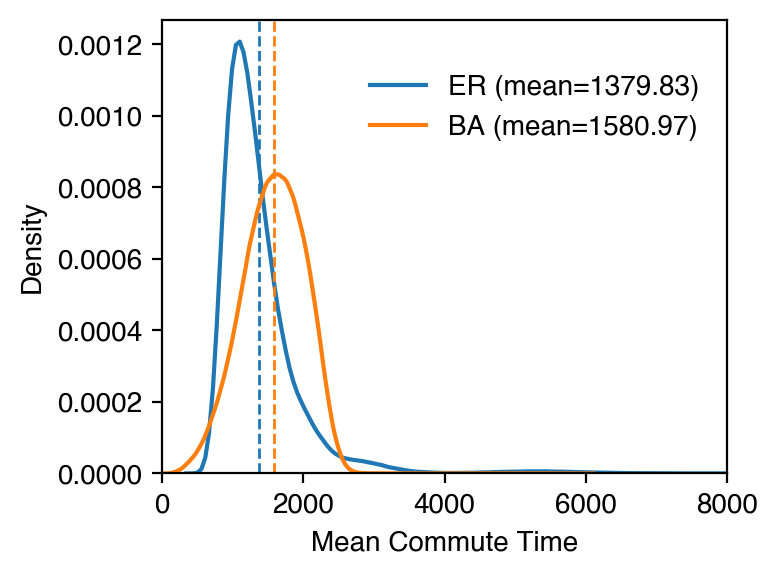

In [150]:
fig, ax = plt.subplots(1,1, figsize=(4,3))

# plotting function
sns.kdeplot(mct_ERs, ax=ax, label=f"ER (mean={np.mean(mct_ERs):.2f})", color='tab:blue', zorder=1)
sns.kdeplot(mct_BAs, ax=ax, label=f"BA (mean={np.mean(mct_BAs):.2f})", color='tab:orange', zorder=2)

ax.axvline(np.mean(mct_ERs), color='tab:blue', linestyle='--', linewidth=1, zorder=1)
ax.axvline(np.mean(mct_BAs), color='tab:orange', linestyle='--', linewidth=1, zorder=2)

# ax.axvline(np.median(mct_ERs), color='blue', linestyle=':', linewidth=1)
# ax.axvline(np.median(mct_BAs), color='orange', linestyle=':', linewidth=1)

ax.set_title("", loc='left')
ax.set_xlabel("Mean Commute Time")
ax.set_ylabel("Density")

ax.set_xlim(0, 8000)

fig.legend(bbox_to_anchor=(0.92, 0.9), frameon=False)
fig.tight_layout()

fig.savefig('figure/mct_comparison_kde.pdf', bbox_inches='tight')

plt.show()

#### Calculating MCT (ver2): 1000 iteration for MFPT on Slurm
This is the implementation that uses Slurm. MCT calculation for all pairs of nodes in 10+10 graphs are distributed over multiple computing nodes. This way, we can scale the computation for larger iterations for MFPT.

The Python script used here for calculation is `mct.py`. We call this script like this from the batch file:
```sh
python mct.py --graph_type "ER" --niter 2000 --items_per_task 1500
```

Overview of the batch job is as following. We repeat the following batch for ER and BA networks.
- For each array tasks in a Slurm batch job, it will compute MCT for `items_per_task` pairs. It will export a CSV with graph ID, node pairs, and MCT. There are `items_per_task` lines in this CSV.
- Such task is repeated until the calculation is completed for all node pairs.

Once the batch job is completed, we load all the saved CSVs, concatenate it, and compute the distribution and mean.

In [11]:
import pandas as pd

##### Generate all combinations of node pairs in all graphs
We first generate a CSV that has all node pairs (around 1250000 pairs for one type of network), that would be loaded in the batch file.

In [12]:
from itertools import combinations

In [ ]:
all_pairs_dicts_ER = []
for graph_id in range(len(G_ERs_LCC)):
    
    G_ER = G_ERs_LCC[graph_id]
    all_pairs = list(combinations(list(G_ER.nodes()), 2))
    for (i,j) in all_pairs:
        all_pairs_dicts_ER.append({
            'graph_id': graph_id,
            'i': i,
            'j': j
        })

In [ ]:
# pd.DataFrame(all_pairs_dicts_ER).to_csv("out/all_pairs_dicts_ER.csv", index=False)

In [ ]:
all_pairs_dicts_BA = []
for graph_id in range(len(G_BAs_LCC)):
    
    G_BA = G_BAs_LCC[graph_id]
    all_pairs = list(combinations(list(G_BA.nodes()), 2))
    for (i,j) in all_pairs:
        all_pairs_dicts_BA.append({
            'graph_id': graph_id,
            'i': i,
            'j': j
        })

In [ ]:
# pd.DataFrame(all_pairs_dicts_BA).to_csv("out/all_pairs_dicts_BA.csv", index=False)

##### Run batch on Slurm
Batch files are stored in `mct/` directory

```sh
sbatch mct_batch_er.sh
sbatch mct_batch_ba.sh
```

##### BA results

In [13]:
import glob

In [14]:
file_paths_BA = glob.glob("out/slurm/mct_BA_1000it*")
df_BA = pd.concat([pd.read_csv(file, header=None) for file in file_paths_BA], ignore_index=True)
df_BA.columns = ['graph_id', 'i', 'j', 'mct']
df_BA.sort_values(by=['graph_id', 'i', 'j'], ascending=True)

,graph_id,i,j,mct
0,0,0,1,241.620
1,0,0,2,172.577
2,0,0,3,457.530
3,0,0,4,205.523
4,0,0,5,181.698
...,...,...,...,...
1221995,9,496,498,2158.256
1221996,9,496,499,2326.911
1221997,9,497,498,2180.653
1221998,9,497,499,2257.266


In [ ]:
# Calculate mean MCT for each graph
for i in range(10):
    print(
        "graph #{}: {:.2f}".format(
            i,
            np.mean(df_BA.query(f"graph_id == {i}")['mct'])
        )
    )

graph #0: 1581.16
graph #1: 1587.57
graph #2: 1580.59
graph #3: 1577.37
graph #4: 1579.43
graph #5: 1585.96
graph #6: 1575.33
graph #7: 1588.96
graph #8: 1573.45
graph #9: 1594.00


In [ ]:
# Check number of pairs
for i in range(10):
    print(len(df_BA.query(f"graph_id == {i}")))

124750
124750
124750
124750
124750
124750
124750
124750
124750
124750


In [ ]:
# Mean
np.mean(df_BA['mct'])

np.float64(1582.3827031967942)

##### ER results

In [16]:
file_paths_ER = glob.glob("out/slurm/mct_ER_1000it*")
df_ER = pd.concat([pd.read_csv(file, header=None) for file in file_paths_ER], ignore_index=True)
df_ER.columns = ['graph_id', 'i', 'j', 'mct']
df_ER.sort_values(by=['graph_id', 'i', 'j'], ascending=True)

,graph_id,i,j,mct
0,0,0,1,2119.389
1,0,0,2,993.666
2,0,0,3,1156.751
3,0,0,4,1556.204
4,0,0,5,894.153
...,...,...,...,...
1220997,9,496,498,882.554
1220998,9,496,499,1244.829
1220999,9,497,498,1484.436
1221000,9,497,499,1933.280


In [17]:
for i in range(10):
    print(
        "graph #{}: {:.2f}".format(
            i,
            np.mean(df_ER.query(f"graph_id == {i}")['mct'])
        )
    )

graph #0: 1403.77
graph #1: 1406.83
graph #2: 1338.51
graph #3: 1356.11
graph #4: 1387.98
graph #5: 1348.16
graph #6: 1344.78
graph #7: 1348.04
graph #8: 1316.11
graph #9: 1362.12


In [18]:
for i in range(10):
    print(len(df_ER.query(f"graph_id == {i}")))

124750
124750
124251
124750
124251
124750
124750
124750
124750
124750


In [19]:
np.mean(df_ER['mct'])

np.float64(1361.2403873423389)

##### Plot

In [21]:
import seaborn as sns

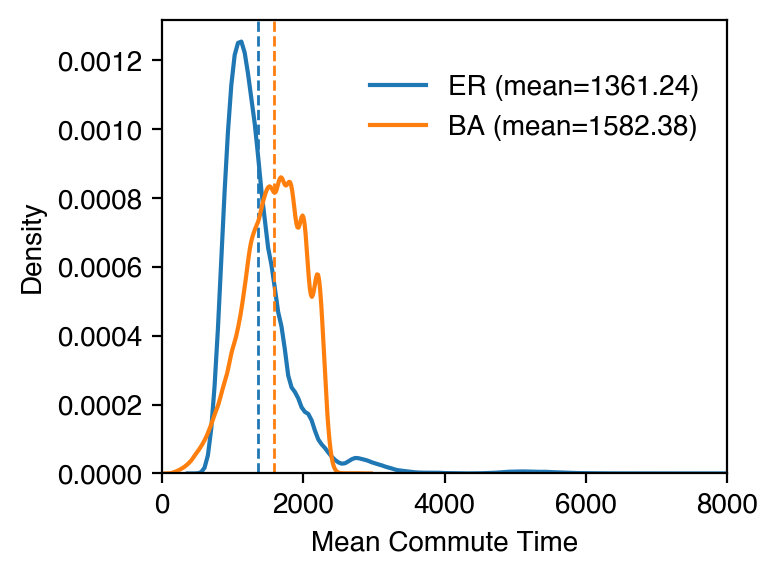

In [22]:
fig, ax = plt.subplots(1,1, figsize=(4,3))

# plotting function
sns.kdeplot(df_ER['mct'], ax=ax, label=f"ER (mean={np.mean(df_ER['mct']):.2f})", color='tab:blue', zorder=1)
sns.kdeplot(df_BA['mct'], ax=ax, label=f"BA (mean={np.mean(df_BA['mct']):.2f})", color='tab:orange', zorder=2)

ax.axvline(np.mean(df_ER['mct']), color='tab:blue', linestyle='--', linewidth=1, zorder=1)
ax.axvline(np.mean(df_BA['mct']), color='tab:orange', linestyle='--', linewidth=1, zorder=2)

# ax.axvline(np.median(df_ER['mct']), color='blue', linestyle=':', linewidth=1)
# ax.axvline(np.median(df_BA['mct']), color='orange', linestyle=':', linewidth=1)

ax.set_title("", loc='left')
ax.set_xlabel("Mean Commute Time")
ax.set_ylabel("Density")

ax.set_xlim(0, 8000)

fig.legend(bbox_to_anchor=(0.92, 0.9), frameon=False)
fig.tight_layout()

# fig.savefig('figure/mct_comparison_kde_1000it.pdf', bbox_inches='tight')

plt.show()